In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Task 1 (Linear Regression Boston Housing Dataset)
# Load the dataset
try:
  df = pd.read_csv('C:/Users/aryam/OneDrive/Desktop/ML/data/housing.csv', delim_whitespace=True, header=None)

except:
  df = pd.read_csv('housing.csv', delim_whitespace=True, header=None)

C:\Users\aryam\AppData\Local\Temp\ipykernel_12132\2305445166.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('C:/Users/aryam/OneDrive/Desktop/ML/data/housing.csv', delim_whitespace=True, header=None)


In [66]:
if df.shape[1] == 14:
    column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
                     'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
    df.columns = column_names
else:
    print(f'Unexpected number of columns: {df.shape}. First row:', df.iloc[0].tolist())
    raise ValueError('Data shape does not match expected format.')

In [ ]:
# Pre_processing

print('\nFirst 5 rows of the dataset:')
print(df.head())



First 5 rows of the dataset:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [68]:
print('\nDataset Information:')
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [69]:
print('\nMissing Values in the Dataset:')
print(df.isnull().sum())


Missing Values in the Dataset:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [70]:
df = df.dropna()

In [ ]:
# Data Preparation

X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
#Train model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#Evaluation

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'\nR^2 Score of the Linear Regression Model: {r2:.4f}')


R^2 Score of the Linear Regression Model: 0.6688


In [ ]:
# Residuals

residuals = y_test - y_pred

In [77]:
residuals

173    -5.396724
274    -3.625565
491    -1.216944
72     -2.231979
452    -2.669880
         ...    
412    18.064237
436    -4.084867
411     1.016403
86      0.223780
75     -3.079024
Name: MEDV, Length: 102, dtype: float64

c:\Users\aryam\OneDrive\Desktop\ML\.venv\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


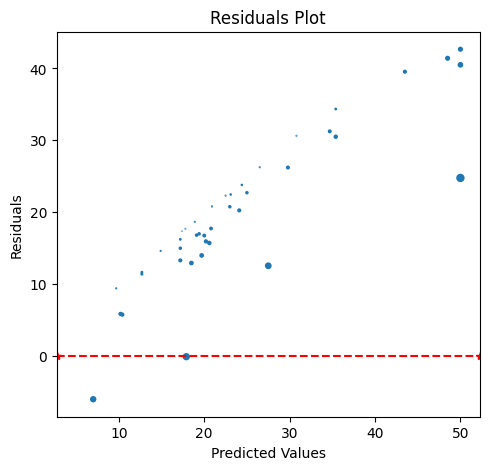

In [ ]:
# Plot using matplotlib

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.axhline(y=0, color='r', linestyle='--', marker='*')

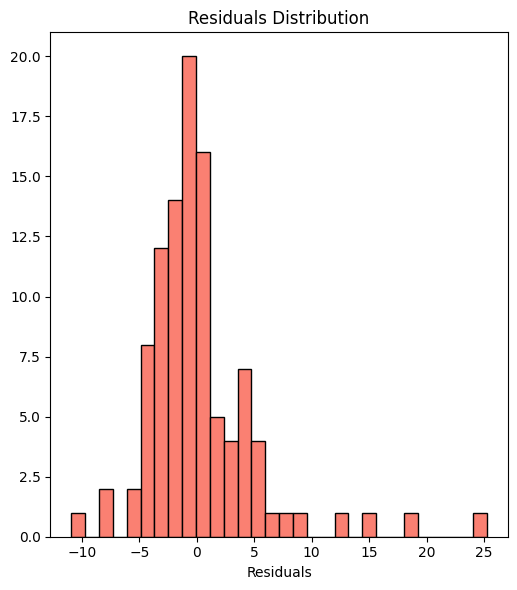

In [ ]:
# plot using seaborn

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='k',color='salmon')
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

In [80]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, 
                           recall_score, f1_score, 
                           confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [83]:
# Task 2 (Logistic Regression Titanic Dataset)

df = pd.read_csv('C:/Users/aryam/OneDrive/Desktop/ML/data/tested.csv')

In [84]:
# Data Preprocessing

print('\nFirst 5 rows of the Titanic dataset:')
print(df.head())


First 5 rows of the Titanic dataset:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [85]:
print('\nDataset Information:')
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


In [86]:
print('\Missing Values in the Titanic Dataset:')
print(df.isnull().sum())

\Missing Values in the Titanic Dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [87]:
df = df.dropna()

In [88]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

In [89]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\aryam\AppData\Local\Temp\ipykernel_12132\1207551879.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\aryam\AppData\Local\Temp\ipykernel_12132\1207551879.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [90]:
X = df[features]
y = df[target]

In [91]:
# Pipeline for preprocessing and model training

numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
])

In [92]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability for ROC curve

In [96]:
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")




Model Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


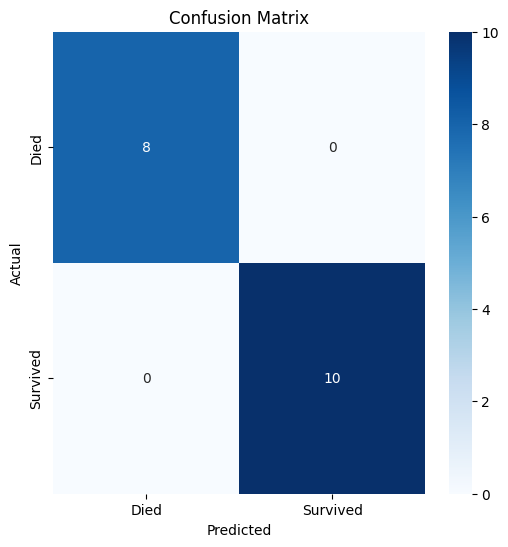

In [97]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

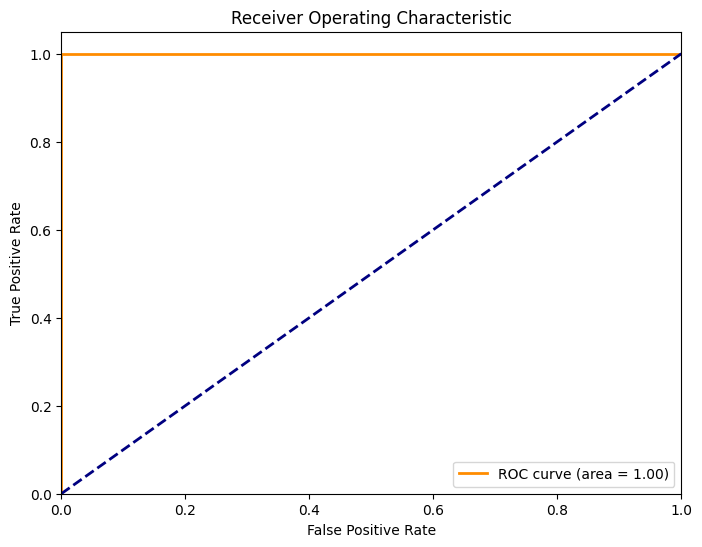

In [98]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [99]:
# Task 3 (KNN Classifier Iris Dataset)

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [100]:
iris = load_iris()
X = iris.data
y = iris.target

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [102]:
# The range of k values to test

k_values = range(1, 31)
euclidean_accuracies = []
manhattan_accuracies = []

In [103]:
# Test each K value with both distance metrics

for k in k_values:

    # Euclidean distance

    knn_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_euclidean.fit(X_train, y_train)
    y_pred_euclidean = knn_euclidean.predict(X_test)
    euclidean_accuracies.append(accuracy_score(y_test, y_pred_euclidean))
    
    # Manhattan distance
    
    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    y_pred_manhattan = knn_manhattan.predict(X_test)
    manhattan_accuracies.append(accuracy_score(y_test, y_pred_manhattan))

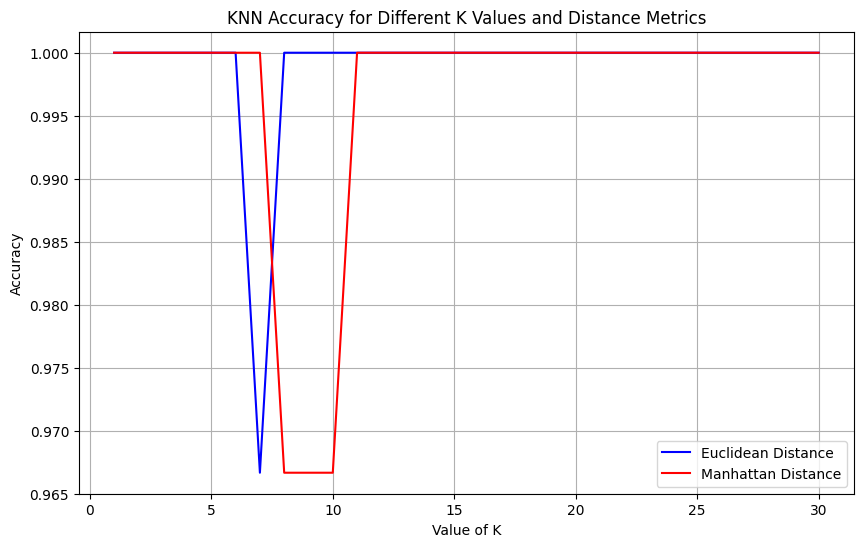

In [104]:
# Plotting the results

plt.figure(figsize=(10, 6))
plt.plot(k_values, euclidean_accuracies, 'b-', label='Euclidean Distance')
plt.plot(k_values, manhattan_accuracies, 'r-', label='Manhattan Distance')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values and Distance Metrics')
plt.legend()
plt.grid(True)
plt.show()

In [110]:
# Find the best K value for each distance metric

best_k_euclidean = k_values[np.argmax(euclidean_accuracies)]
best_k_manhattan = k_values[np.argmax(manhattan_accuracies)]

In [111]:
print(f"Best K with Euclidean distance: {best_k_euclidean} (Accuracy: {max(euclidean_accuracies):.4f})")
print(f"Best K with Manhattan distance: {best_k_manhattan} (Accuracy: {max(manhattan_accuracies):.4f})")

Best K with Euclidean distance: 1 (Accuracy: 1.0000)
Best K with Manhattan distance: 1 (Accuracy: 1.0000)


In [112]:
# Task 4 (SVM Classifier)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn import svm


In [113]:
iris = load_iris()
X = iris.data
y = iris.target

In [114]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
# SVM with different kernels

# Linear Kernel

svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

In [118]:
# RBF Kernel

svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [122]:
# Evaluate the models
print('\nSVM Linear Kernel Classification Report:')
print(classification_report(y_test, y_pred_linear, target_names=iris.target_names))


SVM Linear Kernel Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [123]:
print('\nSVM RBF Kernel Classification Report:')
print(classification_report(y_test, y_pred_rbf, target_names=iris.target_names))


SVM RBF Kernel Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [124]:
# Compare with KNN

# using best KNN from previous task 3 (k=5)

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [125]:
print('n\nKNN Classification Report:')
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names)) 

n
KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [126]:
# Decision Boundary Visualization

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42)

In [127]:
# Train model

svm_linear_2d = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_linear_2d.fit(X_train_2d, y_train_2d)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [129]:
svm_rbf_2d = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf_2d.fit(X_train_2d, y_train_2d)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [130]:
# Meshgrid for decision boundary

def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

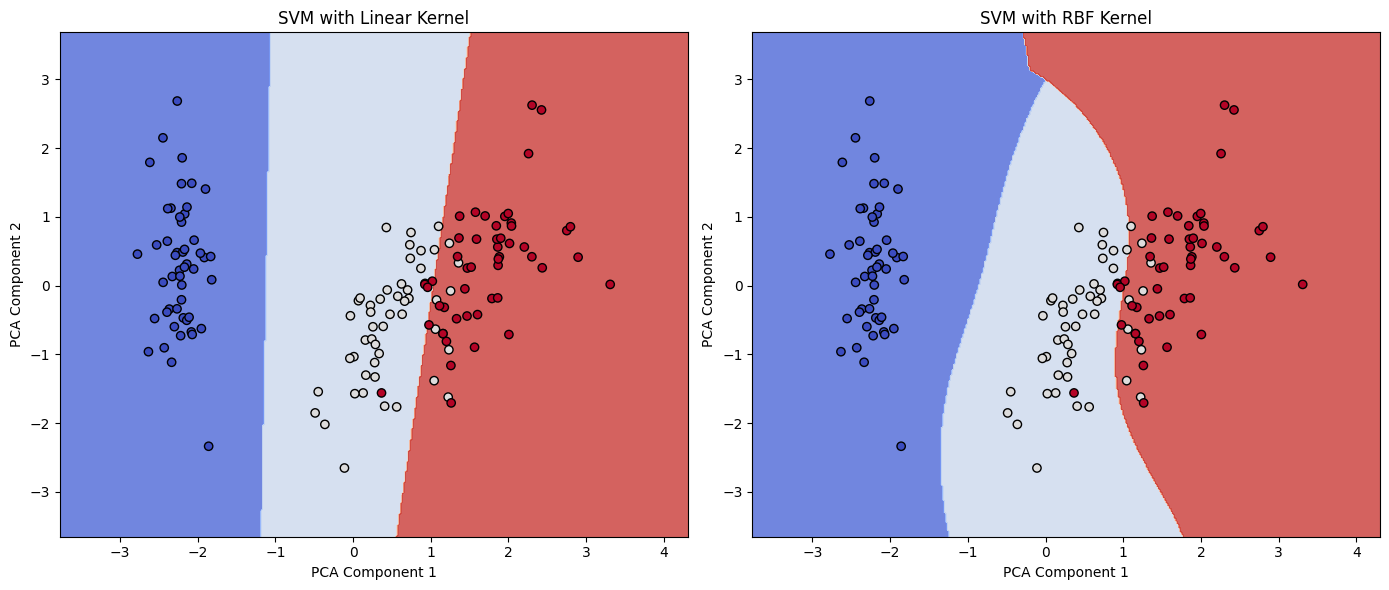

In [134]:
# Plot decision boundaries

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
xx, yy = make_meshgrid(X_2d[:, 0], X_2d[:, 1])

# Linear kernel plot

plot_contours(ax1, svm_linear_2d, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax1.set_title('SVM with Linear Kernel')
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')

# RBF kernel plot

plot_contours(ax2, svm_rbf_2d, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax2.set_title('SVM with RBF Kernel')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()


In [135]:
# Task 5 (Cross Validation and Hyperparameter Tuning)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [136]:
iris = load_iris() 
X = iris.data
y = iris.target

In [137]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [140]:
# KNN Hyperparameter Tuning

knn = KNeighborsClassifier()

In [141]:
# Parametre distribution for KNN

knn_param_dist = {
    'n_neighbors': np.arange(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3]  # Minkowski power parameter
}



In [142]:
# Randomized Search for KNN

knn_random = RandomizedSearchCV(
    estimator=knn,
    param_distributions=knn_param_dist,
    n_iter=50, 
    cv=5,  
    scoring='accuracy',
    random_state=42,
    n_jobs=-1  # Use all available cores
)

In [143]:
knn_random.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': array([ 1, 2..., 27, 28, 29]), 'p': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [144]:
# SVM Hyperparameter Tuning

svm = SVC()

In [145]:
# Define the parameter distribution for SVM

svm_param_dist = {
    'C': np.logspace(-2, 10, 13),  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] + list(np.logspace(-5, 2, 8)),  # Kernel coefficient
    'degree': [2, 3, 4, 5],  # For polynomial kernel
    'coef0': np.linspace(-1, 1, 5)  # For polynomial kernel
}

In [146]:
# Randomized Search for SVM

svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)


In [147]:
svm_random.fit(X_train, y_train)

,estimator,SVC()
,param_distributions,"{'C': array([1.e-02...e+09, 1.e+10]), 'coef0': array([-1. , ..., 0.5, 1. ]), 'degree': [2, 3, ...], 'gamma': ['scale', 'auto', ...], ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [148]:
# Results

print("KNN Best Parameters:", knn_random.best_params_)
print("KNN Best Cross-validated Accuracy: {:.4f}".format(knn_random.best_score_))
print("\nSVM Best Parameters:", svm_random.best_params_)
print("SVM Best Cross-validated Accuracy: {:.4f}".format(svm_random.best_score_))

KNN Best Parameters: {'weights': 'distance', 'p': 3, 'n_neighbors': np.int64(19), 'metric': 'minkowski'}
KNN Best Cross-validated Accuracy: 0.9667

SVM Best Parameters: {'kernel': 'linear', 'gamma': np.float64(1e-05), 'degree': 4, 'coef0': np.float64(0.5), 'C': np.float64(1000000.0)}
SVM Best Cross-validated Accuracy: 0.9583


In [149]:
# Evaluation on Test Set

best_knn = knn_random.best_estimator_
best_svm = svm_random.best_estimator_

print("\nKNN Test Accuracy: {:.4f}".format(best_knn.score(X_test, y_test)))
print("SVM Test Accuracy: {:.4f}".format(best_svm.score(X_test, y_test)))



KNN Test Accuracy: 1.0000
SVM Test Accuracy: 1.0000


In [150]:
# Compare with default parameters

default_knn = KNeighborsClassifier().fit(X_train, y_train)
default_svm = SVC().fit(X_train, y_train)

print("\nDefault KNN Test Accuracy: {:.4f}".format(default_knn.score(X_test, y_test)))
print("Default SVM Test Accuracy: {:.4f}".format(default_svm.score(X_test, y_test)))


Default KNN Test Accuracy: 1.0000
Default SVM Test Accuracy: 1.0000


In [151]:
# Task 6 (Bayesian Optimization)

import numpy as np
from sklearn import svm, datasets
from sklearn.model_selection import cross_val_score
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
import matplotlib.pyplot as plt



In [152]:
iris = load_iris()
X = iris.data
y = iris.target

In [154]:
# Define the parameter distribution for SVM

space = [
    Real(1e-6, 1e+6, prior='log-uniform', name='C'),
    Real(1e-6, 1e+1, prior='log-uniform', name='gamma'),
    Categorical(['linear', 'rbf', 'poly'], name='kernel'),
    Integer(1, 5, name='degree')  # Only used by polynomial kernel
]


In [155]:
# Define the objective function to minimize (negative accuracy)

@use_named_args(space)
def objective(**params):

    # Remove degree parameter if not using polynomial kernel
    
    if params['kernel'] != 'poly':
        params.pop('degree')
    
    model = svm.SVC(**params)
    return -np.mean(cross_val_score(model, X, y, cv=5, n_jobs=-1, scoring="accuracy"))


In [156]:
# Run Bayesian optimization

result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=50,  
    random_state=42,
    n_jobs=-1    # Use all available cores
)


In [157]:
# Print the best results
print(f"Best accuracy: {-result.fun:.4f}")
print("Best parameters:")
print(f"C: {result.x[0]:.4f}")
print(f"gamma: {result.x[1]:.4f}")
print(f"kernel: {result.x[2]}")
print(f"degree: {result.x[3]}")

Best accuracy: 0.9867
Best parameters:
C: 1000000.0000
gamma: 0.0000
kernel: poly
degree: 1


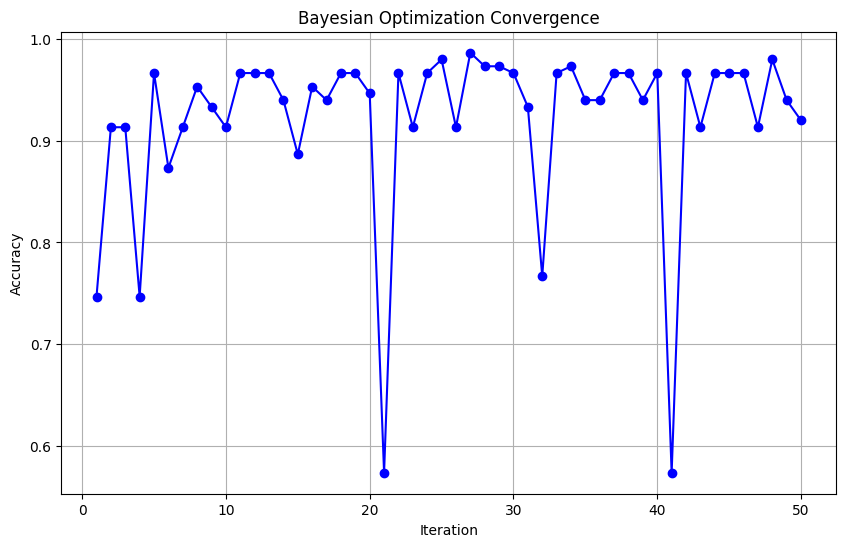

In [ ]:
# Plot convergence

plt.figure(figsize=(10, 6))
plt.plot(range(1, 1+len(result.func_vals)), -result.func_vals, 'bo-')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Bayesian Optimization Convergence')
plt.grid(True)
plt.show()

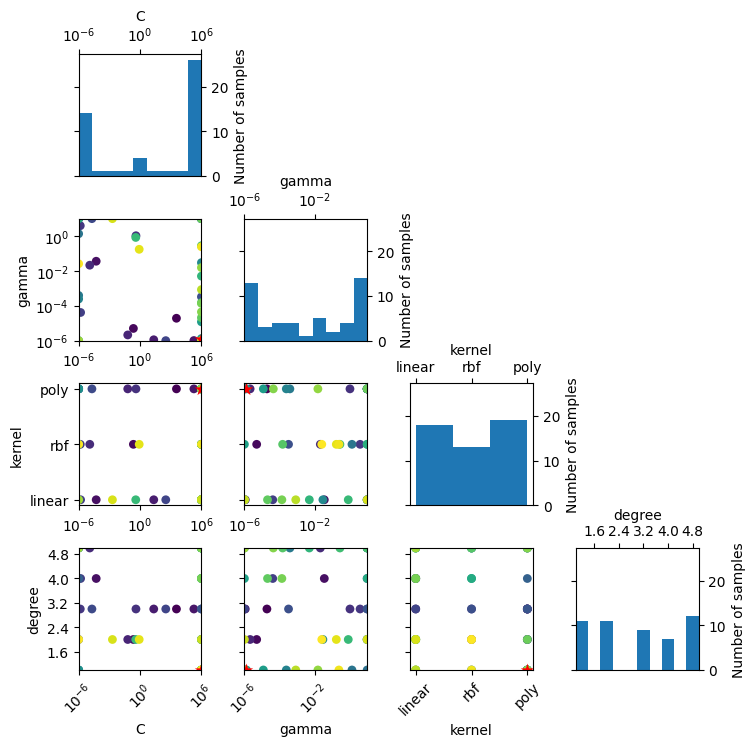

In [159]:
# Plot evaluation points

from skopt.plots import plot_evaluations
plot_evaluations(result, bins=10)
plt.show()

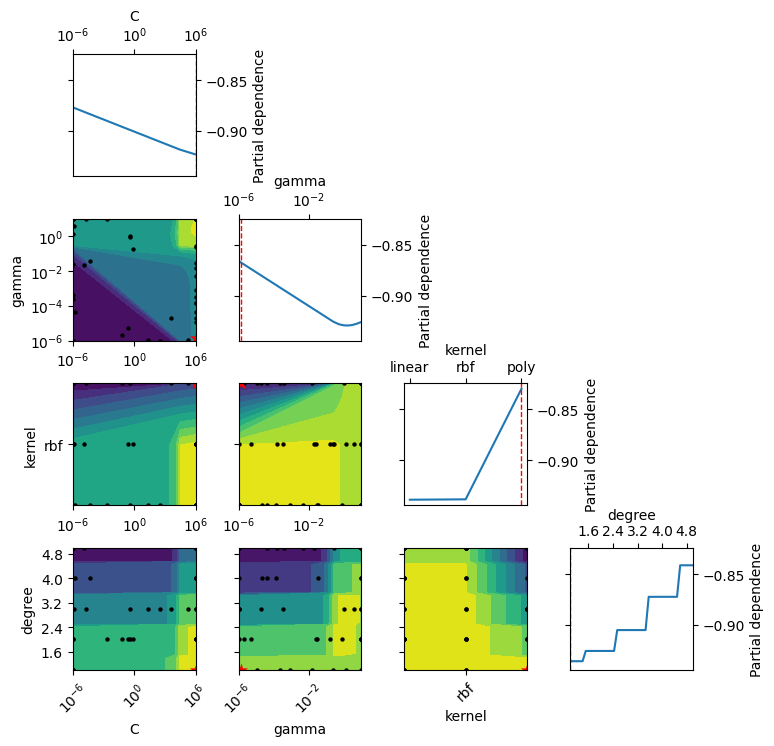

In [160]:
# Plot objective landscape (pairwise)

from skopt.plots import plot_objective
_ = plot_objective(result)
plt.show()